# Bộ dữ liệu 

Retailrocket recommender system dataset

Bộ dữ liệu bao gồm ba tệp: 

    Tệp chứa dữ liệu hành vi (events.csv), 

    tệp chứa thuộc tính mặt hàng (item_properties.csv)  
 
    tệp mô tả cây danh mục (category_tree.csv). 
 
 Dữ liệu được thu thập từ một trang web thương mại điện tử thực tế. Đây là dữ liệu thô, tức là không qua bất kỳ chuyển đổi nội dung nào, tuy nhiên, tất cả các giá trị đều được mã hóa băm do vấn đề bảo mật. Mục đích công bố là để thúc đẩy các nghiên cứu trong lĩnh vực hệ thống đề xuất với phản hồi ngầm.

NỘI DUNG

Dữ liệu hành vi, tức là các sự kiện như nhấp chuột, thêm vào giỏ hàng, giao dịch, thể hiện các tương tác được thu thập trong khoảng thời gian 4,5 tháng. Một khách truy cập có thể thực hiện ba loại sự kiện, đó là "xem", "thêm vào giỏ hàng" hoặc "giao dịch". Tổng cộng có 2.756.101 sự kiện, bao gồm 2.664.312 lượt xem, 69.332 lượt thêm vào giỏ hàng và 22.457 giao dịch được thực hiện bởi 1.407.580 khách truy cập duy nhất. Đối với khoảng 90% sự kiện, các thuộc tính tương ứng có thể được tìm thấy trong tệp "item_properties.csv".

Tệp thuộc tính mặt hàng chứa cột dấu thời gian vì tất cả các thuộc tính đều phụ thuộc vào thời gian, do chúng có thể thay đổi theo thời gian, ví dụ như giá cả, danh mục, v.v. Ban đầu, tệp này bao gồm các bản ghi nhanh cho mỗi tuần trong tệp sự kiện và chứa hơn 200 triệu dòng. Chúng tôi đã hợp nhất các giá trị thuộc tính không đổi liên tiếp, do đó nó đã được chuyển từ dạng bản ghi nhanh sang dạng nhật ký thay đổi. Vì vậy, các giá trị không đổi sẽ chỉ xuất hiện một lần trong tệp. Hành động này đã giảm đáng kể số lượng dòng xuống còn 1/10.

Tất cả các giá trị trong tệp “item_properties.csv”, ngoại trừ thuộc tính “categoryid” và “available”, đều được băm. Giá trị của thuộc tính “categoryid” chứa mã định danh danh mục mặt hàng. Giá trị của thuộc tính “available” chứa thông tin về tình trạng sẵn có của mặt hàng, ví dụ: 1 nghĩa là mặt hàng có sẵn, ngược lại là 0. 

Tệp cây danh mục có 1669 hàng. Mỗi hàng trong tệp chỉ định một ID danh mục con và danh mục cha tương ứng.


1. Khai báo thư viện


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder  
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils.rnn import pack_padded_sequence
import torch.nn as nn
from collections import defaultdict
import time
import random
import pickle


In [2]:
# Thiết lập seed để kết quả có thể tái lập
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# Dữ liệu hành vi
data_events = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/events.csv")
data_events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [4]:
#Dữ liệu cây danh mục
data_categorytree = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/category_tree.csv")
data_categorytree.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [5]:
#Dữ liệu thuộc tính mặt hàng
data_item1 = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/item_properties_part1.csv")
print("Kích thước file:", data_item1.shape)
data_item1.head()

Kích thước file: (10999999, 4)


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [6]:
#Dữ liệu thuộc tính mặt hàng
data_item2 = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/item_properties_part2.csv")
print("Kích thước file:", data_item2.shape)
data_item2.head()

Kích thước file: (9275903, 4)


,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


# 2. Xử lý dữ liệu


Với file item_properties_part1.csv 


Vì ở file category_tree chỉ có categoryid



In [7]:
# Lọc property chỉ còn categoryid, available
data_item1 = data_item1[data_item1["property"].isin(["categoryid", "available"])]
data_item1.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
5,1436065200000,285026,available,0
15,1437274800000,186518,available,0
79,1433646000000,423682,available,0
82,1434250800000,316253,available,1


In [8]:
# Lọc property chỉ còn categoryid, available
data_item2 = data_item2[data_item2["property"].isin(["categoryid", "available"])]
data_item2.head()

,timestamp,itemid,property,value
15,1431226800000,8921,categoryid,1188
31,1433041200000,352564,available,0
43,1431831600000,106601,available,0
65,1437274800000,17166,available,1
70,1433041200000,122405,categoryid,769


In [9]:
# Gộp 2 file item
data_item = pd.concat([data_item1, data_item2])
data_item.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
5,1436065200000,285026,available,0
15,1437274800000,186518,available,0
79,1433646000000,423682,available,0
82,1434250800000,316253,available,1


In [10]:
# convert timestamp 
data_item["timestamp"] = pd.to_datetime(data_item["timestamp"], unit="ms") 
# sort 
data_item = data_item.sort_values("timestamp") 
data_item = data_item.groupby(["itemid", "property"]).last().reset_index()
data_item.head()

,itemid,property,timestamp,value
0,0,available,2015-05-17 03:00:00,0
1,0,categoryid,2015-05-10 03:00:00,209
2,1,available,2015-09-13 03:00:00,0
3,1,categoryid,2015-05-10 03:00:00,1114
4,2,available,2015-06-28 03:00:00,0


In [11]:
# pivot
data_item = data_item.pivot(
    index="itemid",
    columns="property",
    values="value",
).reset_index()
data_item.head()

property,itemid,available,categoryid
0,0,0,209
1,1,0,1114
2,2,0,1305
3,3,0,1171
4,4,0,1038


File event.csv


In [12]:
# Loại bỏ cột transactionid
data_events = data_events[["visitorid", "itemid", "timestamp", "event"]]
data_events.head()

,visitorid,itemid,timestamp,event
0,257597,355908,1433221332117,view
1,992329,248676,1433224214164,view
2,111016,318965,1433221999827,view
3,483717,253185,1433221955914,view
4,951259,367447,1433221337106,view


In [13]:
print("===== DATASET OVERVIEW =====")
print("Số lượng users:",
      data_events['visitorid'].nunique())
print("Số lượng items:",
      data_events['itemid'].nunique())
print("Số lượng interactions:",
      len(data_events))


===== DATASET OVERVIEW =====
Số lượng users: 1407580
Số lượng items: 235061
Số lượng interactions: 2756101



===== EVENT TYPES =====
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64
visitorid    0
itemid       0
timestamp    0
event        0
dtype: int64


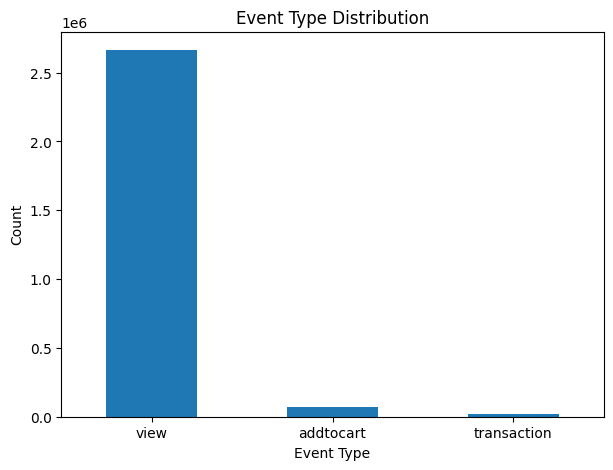

In [14]:
print("\n===== EVENT TYPES =====")
print(data_events['event'].value_counts())
print(data_events.isnull().sum())
plt.figure(figsize=(7,5))
data_events['event'].value_counts().plot(
    kind='bar'
)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [15]:
# Chuyển từ dạng số sang dạng thời gian
data_events["timestamp"] = pd.to_datetime(data_events["timestamp"], unit="ms")
#Sắp xếp theo thời gian,user
data_events = data_events.sort_values(["visitorid", "timestamp"])
data_events.head()

,visitorid,itemid,timestamp,event
1361687,0,285930,2015-09-11 20:49:49.439,view
1367212,0,357564,2015-09-11 20:52:39.591,view
1367342,0,67045,2015-09-11 20:55:17.175,view
830385,1,72028,2015-08-13 17:46:06.444,view
742616,2,325215,2015-08-07 17:51:44.567,view


In [16]:
# Ghép file item + event
data_events = data_events.merge(data_item, on="itemid", how="left")
data_events.head()

,visitorid,itemid,timestamp,event,available,categoryid
0,0,285930,2015-09-11 20:49:49.439,view,1,1188
1,0,357564,2015-09-11 20:52:39.591,view,1,256
2,0,67045,2015-09-11 20:55:17.175,view,1,333
3,1,72028,2015-08-13 17:46:06.444,view,0,1192
4,2,325215,2015-08-07 17:51:44.567,view,1,299


In [17]:
# Kiểm tra dữ liệu trống
data_events.isnull().sum()

visitorid          0
itemid             0
timestamp          0
event              0
available     255585
categoryid    255585
dtype: int64

In [18]:
# Thay giá trị  trống bằng -1
data_events["categoryid"] = data_events["categoryid"].fillna(-1)
data_events["available"] = data_events["available"].fillna(-1)
data_events.isnull().sum()

visitorid     0
itemid        0
timestamp     0
event         0
available     0
categoryid    0
dtype: int64

In [19]:
print("===== DATASET OVERVIEW SAU KHI GHÉP =====")
print("Số lượng users:", data_events["visitorid"].nunique())
print("Số lượng items:", data_events["itemid"].nunique())
print("Số lượng interactions:", len(data_events))

print("\n===== EVENT TYPES =====")
print(data_events["event"].value_counts())

print("\n===== MISSING VALUES =====")
print(data_events.isnull().sum())

print("\n===== CATEGORY =====")
print("Số category:", data_events["categoryid"].nunique())
print("Số available:", data_events["available"].nunique())

===== DATASET OVERVIEW SAU KHI GHÉP =====
Số lượng users: 1407580
Số lượng items: 235061
Số lượng interactions: 2756101

===== EVENT TYPES =====
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

===== MISSING VALUES =====
visitorid     0
itemid        0
timestamp     0
event         0
available     0
categoryid    0
dtype: int64

===== CATEGORY =====
Số category: 1087
Số available: 3


In [20]:
# Tạo chuỗi theo mã người dùng
user_sequences = data_events.groupby("visitorid")["itemid"].apply(list)
user_sequences.head()

visitorid
0                              [285930, 357564, 67045]
1                                              [72028]
2    [325215, 325215, 259884, 216305, 342816, 34281...
3                                             [385090]
4                                             [177677]
Name: itemid, dtype: object

===== THỐNG KÊ ĐỘ DÀI CHUỖI BAN ĐẦU =====
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: itemid, dtype: float64


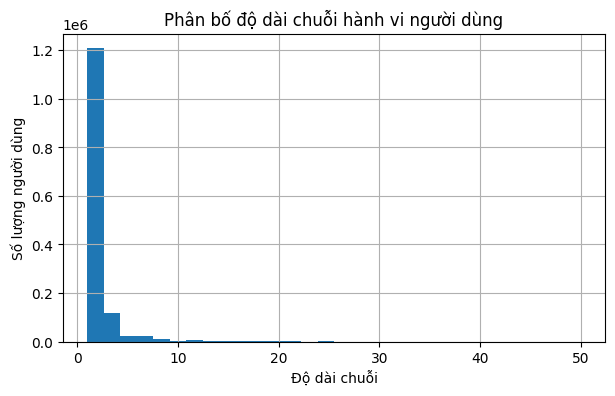

In [21]:
seq_lengths_all = user_sequences.apply(len)

print("===== THỐNG KÊ ĐỘ DÀI CHUỖI BAN ĐẦU =====")
print(seq_lengths_all.describe())

plt.figure(figsize=(7,4))
seq_lengths_all[seq_lengths_all <= 50].hist(bins=30)
plt.title("Phân bố độ dài chuỗi hành vi người dùng")
plt.xlabel("Độ dài chuỗi")
plt.ylabel("Số lượng người dùng")
plt.show()

# 4. Chuẩn bị hàm dùng chung cho tuning và huấn luyện

Phần này định nghĩa các hàm dùng chung để có thể thử nhiều cấu hình khác nhau một cách nhất quán.  
Flow thực nghiệm sau đó sẽ là:

1. Tuning nhẹ phần lọc chuỗi (`min_seq_len`, `max_seq_len`)  
2. Chọn cấu hình chuỗi tốt nhất theo validation NDCG@10  
3. Tuning mạnh hơn cho siêu tham số mô hình LSTM  
4. Train/evaluate mô hình chính thức và so sánh với GRU, Popularity, Data Augmentation


In [22]:
class SimpleSeqDataset(Dataset):
    def __init__(self, samples, max_len=50):
        self.samples = samples
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]

        if len(input_seq) > self.max_len:
            input_seq = input_seq[-self.max_len:]

        return (
            torch.tensor(input_seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long)
        )


def collate_fn(batch):
    inputs, targets = zip(*batch)

    inputs_padded = pad_sequence(
        inputs,
        batch_first=True,
        padding_value=0
    ).contiguous()

    targets = torch.stack(targets)

    return inputs_padded, targets


class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            num_layers=1
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size + 2)

    def forward(self, x):
        mask = (x != 0)
        lengths = mask.sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        x_embed = self.embedding(x)

        packed = pack_padded_sequence(
            x_embed,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h, _) = self.lstm(packed)
        last_hidden = self.dropout(h[-1])
        logits = self.fc(last_hidden)

        return logits


class SimpleGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size + 2)

    def forward(self, x):
        mask = (x != 0)
        lengths = mask.sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        x_embed = self.embedding(x)

        packed = pack_padded_sequence(
            x_embed,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, h = self.gru(packed)
        last_hidden = self.dropout(h[-1])
        logits = self.fc(last_hidden)

        return logits


In [23]:
def prepare_data(
    user_sequences,
    min_seq_len=3,
    max_seq_len=50,
    train_sample_limit=300000,
    batch_size=256,
    seed=42
):
    """Lọc chuỗi, truncate, mapping item, chia train/val/test và tạo DataLoader."""

    filtered_sequences = user_sequences[
        user_sequences.str.len() >= min_seq_len
    ].apply(lambda x: x[-max_seq_len:])

    all_items = sorted({item for seq in filtered_sequences for item in seq})

    item2idx = {
        item: idx + 1
        for idx, item in enumerate(all_items)
    }

    idx2item = {
        idx: item
        for item, idx in item2idx.items()
    }

    vocab_size = len(item2idx)

    sequences_idx = [
        [item2idx[item] for item in seq]
        for seq in filtered_sequences
    ]

    train_samples = []
    val_samples = []
    test_samples = []

    for seq in sequences_idx:
        if len(seq) < 3:
            continue

        train_seq = seq[:-2]

        for i in range(1, len(train_seq)):
            input_seq = train_seq[max(0, i - max_seq_len):i]
            target = train_seq[i]
            train_samples.append((input_seq, target))

            if train_sample_limit is not None and len(train_samples) >= train_sample_limit:
                break

        val_samples.append((seq[:-2][-max_seq_len:], seq[-2]))
        test_samples.append((seq[:-1][-max_seq_len:], seq[-1]))

        if train_sample_limit is not None and len(train_samples) >= train_sample_limit:
            # vẫn giữ val/test đã tạo tới thời điểm này để tuning chạy nhanh
            break

    train_dataset = SimpleSeqDataset(train_samples, max_len=max_seq_len)
    val_dataset = SimpleSeqDataset(val_samples, max_len=max_seq_len)
    test_dataset = SimpleSeqDataset(test_samples, max_len=max_seq_len)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    data_info = {
        "min_seq_len": min_seq_len,
        "max_seq_len": max_seq_len,
        "num_sequences": len(filtered_sequences),
        "num_train_samples": len(train_samples),
        "num_val_samples": len(val_samples),
        "num_test_samples": len(test_samples),
        "avg_seq_len": filtered_sequences.apply(len).mean(),
        "vocab_size": vocab_size,
        "item2idx": item2idx,
        "idx2item": idx2item,
        "filtered_sequences": filtered_sequences
    }

    return train_loader, val_loader, test_loader, data_info


def train_model(model, train_loader, optimizer, criterion, epochs=3):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, targets)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / max(1, len(train_loader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


def evaluate_fast(model, loader, k=10):
    model.eval()
    HR, NDCG = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = model(inputs)
            topk = torch.topk(logits, k=k).indices
            targets_view = targets.view(-1, 1)

            hits = (topk == targets_view)
            hit_any = hits.any(dim=1)

            HR.extend(hit_any.float().cpu().numpy())

            for i, row in enumerate(hits):
                if hit_any[i]:
                    rank = torch.where(row)[0][0].item()
                    NDCG.append(1 / np.log2(rank + 2))
                else:
                    NDCG.append(0)

    return float(np.mean(HR)), float(np.mean(NDCG))


# 5. Tuning nhẹ cho tham số lọc chuỗi

Phần này chỉ tuning nhẹ các tham số tiền xử lý chuỗi.  
Mỗi cấu hình được train nhanh bằng một LSTM nhỏ và đánh giá trên validation set.  
Mục tiêu là chọn cấu hình chuỗi hợp lý trước khi tuning mô hình chính.

In [24]:
seq_tuning_results = []

min_seq_len_list = [2, 3, 5]
max_seq_len_list = [20, 50, 100]

for min_seq_len in min_seq_len_list:
    for max_seq_len in max_seq_len_list:
        print("\n==============================")
        print(f"Tuning sequence: min_seq_len={min_seq_len}, max_seq_len={max_seq_len}")

        train_loader, val_loader, test_loader, info = prepare_data(
            user_sequences=user_sequences,
            min_seq_len=min_seq_len,
            max_seq_len=max_seq_len,
            train_sample_limit=150000,
            batch_size=256
        )

        model = SimpleLSTM(
            vocab_size=info["vocab_size"],
            embed_dim=64,
            hidden_dim=128,
            dropout=0.2
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss(ignore_index=0)

        train_model(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            epochs=2
        )

        val_hr, val_ndcg = evaluate_fast(model, val_loader, k=10)

        seq_tuning_results.append({
            "min_seq_len": min_seq_len,
            "max_seq_len": max_seq_len,
            "num_sequences": info["num_sequences"],
            "num_train_samples": info["num_train_samples"],
            "avg_seq_len": round(info["avg_seq_len"], 2),
            "vocab_size": info["vocab_size"],
            "val_HR@10": val_hr,
            "val_NDCG@10": val_ndcg
        })

seq_tuning_df = pd.DataFrame(seq_tuning_results)
seq_tuning_df.sort_values("val_NDCG@10", ascending=False)



Tuning sequence: min_seq_len=2, max_seq_len=20
Epoch 1/2, Loss: 10.8463
Epoch 2/2, Loss: 8.8746

Tuning sequence: min_seq_len=2, max_seq_len=50
Epoch 1/2, Loss: 10.7681
Epoch 2/2, Loss: 8.7604

Tuning sequence: min_seq_len=2, max_seq_len=100
Epoch 1/2, Loss: 10.7338
Epoch 2/2, Loss: 8.7806

Tuning sequence: min_seq_len=3, max_seq_len=20
Epoch 1/2, Loss: 10.7291
Epoch 2/2, Loss: 8.7745

Tuning sequence: min_seq_len=3, max_seq_len=50
Epoch 1/2, Loss: 10.6230
Epoch 2/2, Loss: 8.6829

Tuning sequence: min_seq_len=3, max_seq_len=100
Epoch 1/2, Loss: 10.5874
Epoch 2/2, Loss: 8.6649

Tuning sequence: min_seq_len=5, max_seq_len=20
Epoch 1/2, Loss: 10.5160
Epoch 2/2, Loss: 8.5302

Tuning sequence: min_seq_len=5, max_seq_len=50
Epoch 1/2, Loss: 10.4192
Epoch 2/2, Loss: 8.4424

Tuning sequence: min_seq_len=5, max_seq_len=100
Epoch 1/2, Loss: 10.4110
Epoch 2/2, Loss: 8.4901


,min_seq_len,max_seq_len,num_sequences,num_train_samples,avg_seq_len,vocab_size,val_HR@10,val_NDCG@10
6,5,20,81620,150000,8.74,92134,0.239895,0.199012
7,5,50,81620,150000,9.75,96008,0.225733,0.186734
8,5,100,81620,150000,10.17,97949,0.221121,0.181701
3,3,20,200028,150000,5.53,124949,0.155137,0.128260
0,2,20,406020,150000,3.74,159259,0.150266,0.123598
1,2,50,406020,150000,3.95,161633,0.141606,0.116217
4,3,50,200028,150000,5.95,127901,0.140609,0.115964
5,3,100,200028,150000,6.12,129399,0.136193,0.110638
2,2,100,406020,150000,4.03,162865,0.132914,0.108437


In [25]:
best_seq_config = seq_tuning_df.sort_values(
    "val_NDCG@10",
    ascending=False
).iloc[0]

best_min_seq_len = int(best_seq_config["min_seq_len"])
best_max_seq_len = int(best_seq_config["max_seq_len"])

print("Best sequence config:")
print(best_seq_config)


Best sequence config:
min_seq_len               5.000000
max_seq_len              20.000000
num_sequences         81620.000000
num_train_samples    150000.000000
avg_seq_len               8.740000
vocab_size            92134.000000
val_HR@10                 0.239895
val_NDCG@10               0.199012
Name: 6, dtype: float64


# 6. Xây dựng dữ liệu chính thức sau khi chọn cấu hình chuỗi

Sau khi tuning nhẹ phần lọc chuỗi, notebook xây dựng lại train/validation/test theo cấu hình tốt nhất.  
Các phần tuning mô hình, so sánh baseline và augmentation sẽ dùng dữ liệu này.

In [26]:
train_loader, val_loader, test_loader, data_info = prepare_data(
    user_sequences=user_sequences,
    min_seq_len=best_min_seq_len,
    max_seq_len=best_max_seq_len,
    train_sample_limit=500000,
    batch_size=256
)

vocab_size = data_info["vocab_size"]
item2idx = data_info["item2idx"]
idx2item = data_info["idx2item"]
user_sequences_filtered = data_info["filtered_sequences"]

print("Số sequence chính thức:", data_info["num_sequences"])
print("Số train samples:", data_info["num_train_samples"])
print("Số val samples:", data_info["num_val_samples"])
print("Số test samples:", data_info["num_test_samples"])
print("Vocab size:", vocab_size)
print("Best min_seq_len:", best_min_seq_len)
print("Best max_seq_len:", best_max_seq_len)


Số sequence chính thức: 81620
Số train samples: 468253
Số val samples: 81620
Số test samples: 81620
Vocab size: 92134
Best min_seq_len: 5
Best max_seq_len: 20


# 7. Tuning mạnh hơn cho siêu tham số mô hình LSTM

Sau khi cố định cấu hình chuỗi, phần này tuning các siêu tham số chính của mô hình LSTM:

- `embed_dim`
- `hidden_dim`
- `learning_rate`
- `dropout`

Cấu hình tốt nhất được chọn theo validation NDCG@10.

In [27]:
model_tuning_results = []

embed_dim_list = [64, 128]
hidden_dim_list = [64, 128]
learning_rate_list = [0.001, 0.0005]
dropout_list = [0.1, 0.3]

for embed_dim in embed_dim_list:
    for hidden_dim in hidden_dim_list:
        for lr in learning_rate_list:
            for dropout in dropout_list:
                print("\n==============================")
                print(
                    f"Tuning LSTM: embed_dim={embed_dim}, "
                    f"hidden_dim={hidden_dim}, lr={lr}, dropout={dropout}"
                )

                model = SimpleLSTM(
                    vocab_size=vocab_size,
                    embed_dim=embed_dim,
                    hidden_dim=hidden_dim,
                    dropout=dropout
                ).to(device)

                optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                criterion = nn.CrossEntropyLoss(ignore_index=0)

                train_model(
                    model=model,
                    train_loader=train_loader,
                    optimizer=optimizer,
                    criterion=criterion,
                    epochs=3
                )

                val_hr, val_ndcg = evaluate_fast(model, val_loader, k=10)

                model_tuning_results.append({
                    "embed_dim": embed_dim,
                    "hidden_dim": hidden_dim,
                    "learning_rate": lr,
                    "dropout": dropout,
                    "val_HR@10": val_hr,
                    "val_NDCG@10": val_ndcg
                })

model_tuning_df = pd.DataFrame(model_tuning_results)
model_tuning_df.sort_values("val_NDCG@10", ascending=False)



Tuning LSTM: embed_dim=64, hidden_dim=64, lr=0.001, dropout=0.1
Epoch 1/3, Loss: 10.2005
Epoch 2/3, Loss: 8.2428
Epoch 3/3, Loss: 7.0747

Tuning LSTM: embed_dim=64, hidden_dim=64, lr=0.001, dropout=0.3
Epoch 1/3, Loss: 10.4244
Epoch 2/3, Loss: 8.9264
Epoch 3/3, Loss: 7.8820

Tuning LSTM: embed_dim=64, hidden_dim=64, lr=0.0005, dropout=0.1
Epoch 1/3, Loss: 10.5837
Epoch 2/3, Loss: 9.2693
Epoch 3/3, Loss: 8.3292

Tuning LSTM: embed_dim=64, hidden_dim=64, lr=0.0005, dropout=0.3
Epoch 1/3, Loss: 10.6560
Epoch 2/3, Loss: 9.6654
Epoch 3/3, Loss: 8.8723

Tuning LSTM: embed_dim=64, hidden_dim=128, lr=0.001, dropout=0.1
Epoch 1/3, Loss: 9.7759
Epoch 2/3, Loss: 7.3152
Epoch 3/3, Loss: 5.9648

Tuning LSTM: embed_dim=64, hidden_dim=128, lr=0.001, dropout=0.3
Epoch 1/3, Loss: 10.0989
Epoch 2/3, Loss: 8.1160
Epoch 3/3, Loss: 6.8903

Tuning LSTM: embed_dim=64, hidden_dim=128, lr=0.0005, dropout=0.1
Epoch 1/3, Loss: 10.3181
Epoch 2/3, Loss: 8.4495
Epoch 3/3, Loss: 7.2699

Tuning LSTM: embed_dim=64, h

,embed_dim,hidden_dim,learning_rate,dropout,val_HR@10,val_NDCG@10
12,128,128,0.0010,0.1,0.444487,0.361496
4,64,128,0.0010,0.1,0.417263,0.342526
13,128,128,0.0010,0.3,0.414102,0.339520
5,64,128,0.0010,0.3,0.385506,0.318065
14,128,128,0.0005,0.1,0.367888,0.305227
8,128,64,0.0010,0.1,0.369284,0.303460
0,64,64,0.0010,0.1,0.343470,0.282283
9,128,64,0.0010,0.3,0.336658,0.276334
6,64,128,0.0005,0.1,0.332590,0.276101
15,128,128,0.0005,0.3,0.330617,0.274437


In [28]:
best_model_config = model_tuning_df.sort_values(
    "val_NDCG@10",
    ascending=False
).iloc[0]

best_embed_dim = int(best_model_config["embed_dim"])
best_hidden_dim = int(best_model_config["hidden_dim"])
best_lr = float(best_model_config["learning_rate"])
best_dropout = float(best_model_config["dropout"])

print("Best model config:")
print(best_model_config)


Best model config:
embed_dim        128.000000
hidden_dim       128.000000
learning_rate      0.001000
dropout            0.100000
val_HR@10          0.444487
val_NDCG@10        0.361496
Name: 12, dtype: float64


# 8. Train mô hình chính thức và so sánh 2–3 mô hình

Phần này train lại mô hình chính thức bằng cấu hình tốt nhất, sau đó so sánh với các baseline:

1. Popularity Baseline
2. LSTM
3. GRU


In [29]:
def popularity_baseline(train_loader, val_loader, test_loader, k=10):
    item_count = defaultdict(int)

    for inputs, targets in train_loader:
        for target in targets.tolist():
            item_count[target] += 1

    popular_items = [
        item for item, _ in sorted(
            item_count.items(),
            key=lambda x: x[1],
            reverse=True
        )[:k]
    ]

    HR, NDCG = [], []

    for _, targets in test_loader:
        for target in targets.tolist():
            if target in popular_items:
                HR.append(1)
                rank = popular_items.index(target)
                NDCG.append(1 / np.log2(rank + 2))
            else:
                HR.append(0)
                NDCG.append(0)

    return float(np.mean(HR)), float(np.mean(NDCG))


comparison_results = []

pop_hr, pop_ndcg = popularity_baseline(train_loader, val_loader, test_loader, k=10)
comparison_results.append({
    "method": "Popularity",
    "HR@10": pop_hr,
    "NDCG@10": pop_ndcg
})

print("Popularity HR@10:", pop_hr)
print("Popularity NDCG@10:", pop_ndcg)


Popularity HR@10: 0.007853467287429552
Popularity NDCG@10: 0.004252629826437438


In [30]:
# Train LSTM chính thức
lstm_model = SimpleLSTM(
    vocab_size=vocab_size,
    embed_dim=best_embed_dim,
    hidden_dim=best_hidden_dim,
    dropout=best_dropout
).to(device)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=best_lr)
criterion = nn.CrossEntropyLoss(ignore_index=0)

train_model(
    model=lstm_model,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10
)

lstm_hr, lstm_ndcg = evaluate_fast(lstm_model, test_loader, k=10)

comparison_results.append({
    "method": "LSTM",
    "HR@10": lstm_hr,
    "NDCG@10": lstm_ndcg
})

print(f"LSTM HR@10: {lstm_hr:.4f}")
print(f"LSTM NDCG@10: {lstm_ndcg:.4f}")


Epoch 1/10, Loss: 9.6752
Epoch 2/10, Loss: 7.1036
Epoch 3/10, Loss: 5.6790
Epoch 4/10, Loss: 4.7346
Epoch 5/10, Loss: 4.0513
Epoch 6/10, Loss: 3.5315
Epoch 7/10, Loss: 3.1320
Epoch 8/10, Loss: 2.8196
Epoch 9/10, Loss: 2.5799
Epoch 10/10, Loss: 2.3862
LSTM HR@10: 0.4588
LSTM NDCG@10: 0.3634


In [31]:
# Train GRU với cùng cấu hình tốt nhất để so sánh công bằng
gru_model = SimpleGRU(
    vocab_size=vocab_size,
    embed_dim=best_embed_dim,
    hidden_dim=best_hidden_dim,
    dropout=best_dropout
).to(device)

optimizer = torch.optim.Adam(gru_model.parameters(), lr=best_lr)
criterion = nn.CrossEntropyLoss(ignore_index=0)

train_model(
    model=gru_model,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10
)

gru_hr, gru_ndcg = evaluate_fast(gru_model, test_loader, k=10)

comparison_results.append({
    "method": "GRU",
    "HR@10": gru_hr,
    "NDCG@10": gru_ndcg
})

print(f"GRU HR@10: {gru_hr:.4f}")
print(f"GRU NDCG@10: {gru_ndcg:.4f}")


Epoch 1/10, Loss: 9.6680
Epoch 2/10, Loss: 7.0480
Epoch 3/10, Loss: 5.5988
Epoch 4/10, Loss: 4.6291
Epoch 5/10, Loss: 3.9150
Epoch 6/10, Loss: 3.3600
Epoch 7/10, Loss: 2.9366
Epoch 8/10, Loss: 2.6195
Epoch 9/10, Loss: 2.3771
Epoch 10/10, Loss: 2.1861
GRU HR@10: 0.4249
GRU NDCG@10: 0.3342


In [32]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df.sort_values("NDCG@10", ascending=False)


,method,HR@10,NDCG@10
1,LSTM,0.458834,0.363447
2,GRU,0.424945,0.334247
0,Popularity,0.007853,0.004253


# 9. Data Augmentation

Phần này áp dụng các kỹ thuật tăng cường dữ liệu chuỗi trên mô hình LSTM với cấu hình tốt nhất đã tìm được:

- crop
- mask
- reorder
- substitute


In [33]:
def crop(seq):
    if len(seq) <= 2:
        return seq

    start = random.randint(0, len(seq) - 2)
    end = random.randint(start + 1, len(seq))

    return seq[start:end]


MASK_TOKEN = vocab_size + 1


def mask(seq, prob=0.2):
    if len(seq) <= 1:
        return seq

    masked = [
        item if random.random() > prob else MASK_TOKEN
        for item in seq
    ]

    if all(x == MASK_TOKEN for x in masked):
        idx = random.randint(0, len(seq) - 1)
        masked[idx] = seq[idx]

    return masked


def reorder(seq, window=3, n_times=2):
    seq = seq.copy()

    if len(seq) < window:
        return seq

    for _ in range(n_times):
        start = random.randint(0, len(seq) - window)
        sub = seq[start:start + window]
        random.shuffle(sub)
        seq[start:start + window] = sub

    return seq


def substitute(seq, item2cat, cat2items, prob=0.2):
    new_seq = []

    for item in seq:
        if random.random() < prob:
            cat = item2cat.get(item)

            if cat is not None and cat in cat2items:
                new_item = random.choice(cat2items[cat])
                new_seq.append(new_item)
            else:
                new_seq.append(item)
        else:
            new_seq.append(item)

    return new_seq


In [34]:
class AugDataset(Dataset):
    def __init__(
        self,
        samples,
        aug_type=None,
        item2cat=None,
        cat2items=None,
        max_len=50,
        aug_prob=0.5
    ):
        self.samples = samples
        self.aug_type = aug_type
        self.item2cat = item2cat
        self.cat2items = cat2items
        self.max_len = max_len
        self.aug_prob = aug_prob

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]
        input_seq = input_seq.copy()

        if self.aug_type and random.random() < self.aug_prob:
            if self.aug_type == "crop":
                input_seq = crop(input_seq)
            elif self.aug_type == "mask":
                input_seq = mask(input_seq)
            elif self.aug_type == "reorder":
                input_seq = reorder(input_seq)
            elif self.aug_type == "substitute":
                if self.item2cat and self.cat2items:
                    input_seq = substitute(input_seq, self.item2cat, self.cat2items)

        if len(input_seq) > self.max_len:
            input_seq = input_seq[-self.max_len:]

        return (
            torch.tensor(input_seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long)
        )


In [35]:
# Mapping category cho substitute augmentation
item2cat_raw = dict(zip(data_item["itemid"], data_item["categoryid"]))

item2cat_idx = {
    item2idx[item]: int(cat)
    for item, cat in item2cat_raw.items()
    if item in item2idx and pd.notna(cat)
}

cat2items_idx = defaultdict(list)

for item, cat in item2cat_raw.items():
    if item in item2idx and pd.notna(cat):
        cat2items_idx[int(cat)].append(item2idx[item])

cat2items_idx = {
    cat: items
    for cat, items in cat2items_idx.items()
    if len(items) >= 2
}

print("Số category dùng cho substitute:", len(cat2items_idx))


Số category dùng cho substitute: 919


In [36]:
# Lấy lại train_samples từ train_loader.dataset để dùng cho augmentation
train_samples_final = train_loader.dataset.samples
aug_results = []

for aug in [None, "crop", "mask", "reorder", "substitute"]:
    print("\n==============================")
    print("Running augmentation:", aug if aug else "Baseline")

    if aug is None:
        aug_train_dataset = SimpleSeqDataset(
            train_samples_final,
            max_len=best_max_seq_len
        )
    elif aug == "substitute":
        aug_train_dataset = AugDataset(
            train_samples_final,
            aug_type=aug,
            item2cat=item2cat_idx,
            cat2items=cat2items_idx,
            max_len=best_max_seq_len,
            aug_prob=0.5
        )
    else:
        aug_train_dataset = AugDataset(
            train_samples_final,
            aug_type=aug,
            max_len=best_max_seq_len,
            aug_prob=0.5
        )

    aug_train_loader = DataLoader(
        aug_train_dataset,
        batch_size=256,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    model = SimpleLSTM(
        vocab_size=vocab_size,
        embed_dim=best_embed_dim,
        hidden_dim=best_hidden_dim,
        dropout=best_dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    train_model(
        model=model,
        train_loader=aug_train_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=10
    )

    hr, ndcg = evaluate_fast(model, test_loader, k=10)

    aug_results.append({
        "method": aug if aug else "LSTM Baseline",
        "HR@10": hr,
        "NDCG@10": ndcg
    })

    print(f"{aug if aug else 'Baseline'} HR@10: {hr:.4f}")
    print(f"{aug if aug else 'Baseline'} NDCG@10: {ndcg:.4f}")

aug_df = pd.DataFrame(aug_results)
aug_df.sort_values("NDCG@10", ascending=False)



Running augmentation: Baseline
Epoch 1/10, Loss: 9.6683
Epoch 2/10, Loss: 7.1028
Epoch 3/10, Loss: 5.6852
Epoch 4/10, Loss: 4.7418
Epoch 5/10, Loss: 4.0592
Epoch 6/10, Loss: 3.5404
Epoch 7/10, Loss: 3.1386
Epoch 8/10, Loss: 2.8257
Epoch 9/10, Loss: 2.5861
Epoch 10/10, Loss: 2.3940
Baseline HR@10: 0.4584
Baseline NDCG@10: 0.3625

Running augmentation: crop
Epoch 1/10, Loss: 9.8248
Epoch 2/10, Loss: 7.5001
Epoch 3/10, Loss: 6.2500
Epoch 4/10, Loss: 5.4214
Epoch 5/10, Loss: 4.8221
Epoch 6/10, Loss: 4.3739
Epoch 7/10, Loss: 4.0248
Epoch 8/10, Loss: 3.7502
Epoch 9/10, Loss: 3.5394
Epoch 10/10, Loss: 3.3713
crop HR@10: 0.4707
crop NDCG@10: 0.3704

Running augmentation: mask
Epoch 1/10, Loss: 9.7471
Epoch 2/10, Loss: 7.2627
Epoch 3/10, Loss: 5.8999
Epoch 4/10, Loss: 5.0005
Epoch 5/10, Loss: 4.3568
Epoch 6/10, Loss: 3.8677
Epoch 7/10, Loss: 3.4938
Epoch 8/10, Loss: 3.1990
Epoch 9/10, Loss: 2.9741
Epoch 10/10, Loss: 2.7975
mask HR@10: 0.4659
mask NDCG@10: 0.3674

Running augmentation: reorder


,method,HR@10,NDCG@10
4,substitute,0.475999,0.373435
1,crop,0.470718,0.370377
2,mask,0.465866,0.367448
3,reorder,0.464310,0.366357
0,LSTM Baseline,0.458405,0.362511


# 10. So sánh và trực quan hóa kết quả cuối cùng

In [37]:
final_results_df = pd.concat([
    comparison_df,
    aug_df
], ignore_index=True)

final_results_df = final_results_df.drop_duplicates(
    subset=["method"],
    keep="last"
)

final_results_df.sort_values("NDCG@10", ascending=False)


,method,HR@10,NDCG@10
7,substitute,0.475999,0.373435
4,crop,0.470718,0.370377
5,mask,0.465866,0.367448
6,reorder,0.464310,0.366357
1,LSTM,0.458834,0.363447
3,LSTM Baseline,0.458405,0.362511
2,GRU,0.424945,0.334247
0,Popularity,0.007853,0.004253


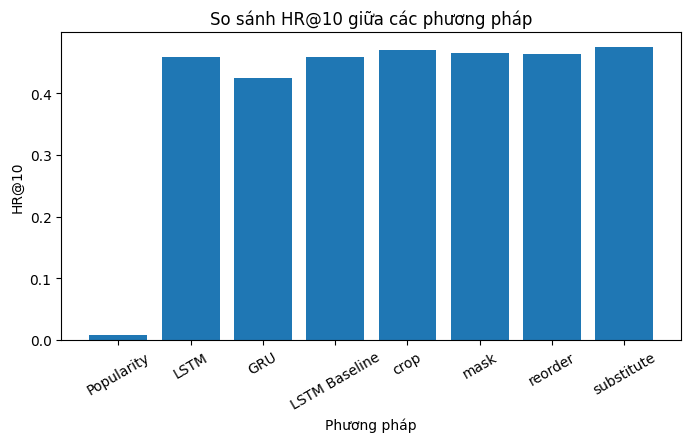

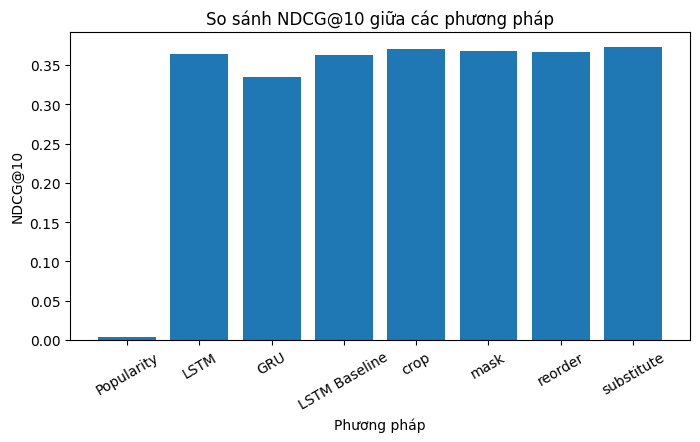

In [38]:
plt.figure(figsize=(8,4))
plt.bar(final_results_df["method"], final_results_df["HR@10"])
plt.title("So sánh HR@10 giữa các phương pháp")
plt.xlabel("Phương pháp")
plt.ylabel("HR@10")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(final_results_df["method"], final_results_df["NDCG@10"])
plt.title("So sánh NDCG@10 giữa các phương pháp")
plt.xlabel("Phương pháp")
plt.ylabel("NDCG@10")
plt.xticks(rotation=30)
plt.show()


# 11. Lưu mô hình và cấu hình phục vụ web demo

In [39]:
# Chọn mô hình LSTM chính thức để lưu cho web demo
# Có thể thay bằng mô hình augmentation tốt nhất nếu muốn deploy phương pháp tốt nhất.
torch.save(lstm_model.state_dict(), "lstm_recommender.pth")

with open("item2idx.pkl", "wb") as f:
    pickle.dump(item2idx, f)

with open("idx2item.pkl", "wb") as f:
    pickle.dump(idx2item, f)

config = {
    "best_min_seq_len": best_min_seq_len,
    "best_max_seq_len": best_max_seq_len,
    "embed_dim": best_embed_dim,
    "hidden_dim": best_hidden_dim,
    "learning_rate": best_lr,
    "dropout": best_dropout,
    "vocab_size": vocab_size,
    "model": "LSTM"
}

with open("model_config.pkl", "wb") as f:
    pickle.dump(config, f)

print("Đã lưu model và các file cấu hình:")
print("- lstm_recommender.pth")
print("- item2idx.pkl")
print("- idx2item.pkl")
print("- model_config.pkl")
print(config)


Đã lưu model và các file cấu hình:
- lstm_recommender.pth
- item2idx.pkl
- idx2item.pkl
- model_config.pkl
{'best_min_seq_len': 5, 'best_max_seq_len': 20, 'embed_dim': 128, 'hidden_dim': 128, 'learning_rate': 0.001, 'dropout': 0.1, 'vocab_size': 92134, 'model': 'LSTM'}


In [40]:
import pickle
import torch
import shutil
import os

SAVE_DIR = "/kaggle/working/model_files"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. lưu model
torch.save(model.state_dict(), f"{SAVE_DIR}/model.pth")

# 2. lưu mapping
with open(f"{SAVE_DIR}/item2idx.pkl", "wb") as f:
    pickle.dump(item2idx, f)

with open(f"{SAVE_DIR}/idx2item.pkl", "wb") as f:
    pickle.dump(idx2item, f)

# 3. nén thành zip để tải về máy
shutil.make_archive(
    "/kaggle/working/model_files",
    "zip",
    SAVE_DIR
)

print("Đã lưu và nén xong!")
print("Tải file này về: /kaggle/working/model_files.zip")

Đã lưu và nén xong!
Tải file này về: /kaggle/working/model_files.zip


# Kết luận thực nghiệm

Notebook thực hiện theo hướng:

1. Tuning nhẹ tham số lọc chuỗi để chọn dữ liệu huấn luyện phù hợp.  
2. Tuning mạnh hơn các siêu tham số chính của mô hình LSTM.  
3. So sánh LSTM với Popularity Baseline và GRU.  
4. Đánh giá các phương pháp Data Augmentation gồm crop, mask, reorder và substitute.  
5. Lưu mô hình và mapping để tích hợp vào web demo.
